# Importing Libraries

In [107]:
import os
import pandas as pd
import numpy as np
import operator

from typing import Literal, TypedDict, Annotated
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv


In [108]:
# Load environment variables from .env file
load_dotenv()

True

In [109]:
# Load OpenAI API key
OPENAI_API_KEY = os.getenv("OPENAI_KEY")

# Creating State Graph

In [110]:
class AgentState(TypedDict):
    dataframe: pd.DataFrame
    numeric_description: str
    categorical_description: str
    combined_insights: str
    recommendation_report: str
    score: int
    feedback_report: str
    counter: int
    
    feedback_history: Annotated[list[str], operator.add]
    score_history: Annotated[list[int], operator.add]
    recommendation_history: Annotated[list[str], operator.add]



# Pydantic class to collect feedback and score

In [111]:
class FeedbackScore(BaseModel):
    feedback: str = Field(description="Feedback to improve the recommendation report")
    score: int = Field(ge=0, le=10, description="Score between 0 and 10")

# Structured LLm Call

In [112]:
llm = ChatOpenAI(
    model="gpt-6-luna",
    api_key=OPENAI_API_KEY
)

structured_llm = llm.with_structured_output(FeedbackScore)

# Creating Functions

In [113]:
def load_data(state: AgentState):
    file_path = os.path.join(os.getcwd(), "data.csv")
    dataframe = pd.read_csv(file_path)
    return {"dataframe": dataframe}

In [114]:
def numerical_analysis(state: AgentState):
    dataframe = state["dataframe"]

    numeric_columns = dataframe.select_dtypes(include=np.number).columns
    numeric_data = dataframe[numeric_columns]

    analysis = pd.DataFrame({
        "data_type": numeric_data.dtypes.astype(str),
        "count": numeric_data.count(),
        "null_count": numeric_data.isnull().sum(),
        "null_percentage": (numeric_data.isnull().mean() * 100).round(2),
        "unique_values": numeric_data.nunique(),
        "mean": numeric_data.mean(),
        "median": numeric_data.median(),
        "std_dev": numeric_data.std(),
        "min": numeric_data.min(),
        "25th_quartile": numeric_data.quantile(0.25),
        "75th_quartile": numeric_data.quantile(0.75),
        "max": numeric_data.max(),
        "iqr": numeric_data.quantile(0.75) - numeric_data.quantile(0.25),
        "skewness": numeric_data.skew()
    })

    numeric_description = analysis.to_string()

    return {"numeric_description": numeric_description}

In [115]:
def categorical_analysis(state: AgentState):
    dataframe = state["dataframe"]

    categorical_columns = dataframe.select_dtypes(
        include=["object", "category", "string"]
    ).columns

    results = []

    for column in categorical_columns:
        data = dataframe[column]
        non_null_data = data.dropna()

        mode = non_null_data.mode()
        most_frequent_value = mode.iloc[0] if not mode.empty else None

        most_frequent_count = (
            non_null_data.value_counts().iloc[0]
            if not non_null_data.empty
            else 0
        )

        results.append({
            "column": column,
            "data_type": str(data.dtype),
            "count": data.count(),
            "null_count": data.isnull().sum(),
            "null_percentage": round(data.isnull().mean() * 100, 2),
            "unique_values": data.nunique(),
            "most_frequent_value": most_frequent_value,
            "most_frequent_count": most_frequent_count,
            "most_frequent_percentage": round(
                (most_frequent_count / len(non_null_data) * 100)
                if len(non_null_data) > 0 else 0,
                2
            ),
            "unique_percentage": round(
                (data.nunique() / len(non_null_data) * 100)
                if len(non_null_data) > 0 else 0,
                2
            )
        })

    analysis = pd.DataFrame(results)
    categorical_description = analysis.to_string(index=False)

    return {"categorical_description": categorical_description}

In [116]:
def combined_analysis(state: AgentState):
    combined_insights = (
        "ANALYSIS OF NUMERICAL COLUMNS:\n"
        + state["numeric_description"]
        + "\n\n"
        + "ANALYSIS OF CATEGORICAL COLUMNS:\n"
        + state["categorical_description"]
    )

    return {"combined_insights": combined_insights}

In [117]:
def write_recommendation(state: AgentState):
    system_prompt = """
    You are an experienced Data Quality Analyst with decades of experience
    in data preprocessing, data cleaning, and improving dataset quality.
    """

    user_prompt = user_prompt = f"""
    We have analyzed the numerical and categorical columns of a dataset.

    Here is the analysis:

    {state["combined_insights"]}

    Your job is to provide a data quality recommendation for EACH column
    in the dataset.

    For each column:
    - Identify any potential data quality issue.
    - Provide a specific recommendation for how to address the issue.
    - Clearly explain the reasoning behind the recommendation.
    - If no action is required, explicitly state that and explain why.
    - Do not exceed 3 lines of recommendation per column.

    Previous feedback:
    {state["feedback_report"]}

    If the previous feedback is not empty, incorporate the feedback into the
    recommendations and rewrite the report accordingly.

    Return the recommendations as a single text report.
    """

    response = llm.invoke([
        ("system", system_prompt),
        ("user", user_prompt)
    ])

    recommendation_report = response.content

    return {
        "recommendation_report": recommendation_report,
        "recommendation_history": [recommendation_report],
        "counter": state["counter"] + 1
    }

In [118]:
def feedback_scoring(state: AgentState):
    system_prompt = """
    You are a very strict and highly critical Senior Data Quality Professional
    with decades of experience in data preprocessing, data cleaning, and
    evaluating data quality recommendations.
    """

    user_prompt = f"""
    Review the following data quality recommendation report:

    {state["recommendation_report"]}

    Critically evaluate the report for accuracy, specificity, completeness,
    reasoning, and usefulness.

    Provide:
    1. Detailed written feedback explaining how the report can be improved.
    2. A score between 1 and 10, where 10 represents an excellent,
       comprehensive, and actionable data quality recommendation report.
    """

    response = structured_llm.invoke([
        ("system", system_prompt),
        ("user", user_prompt)
    ])

    return {
        "feedback_report": response.feedback,
        "score": response.score,
        "feedback_history": [response.feedback],
        "score_history": [response.score]
    }

In [119]:
def approve_condition(state: AgentState):
    if state["score"] >= 8 or state["counter"] > 3:
        print(state["recommendation_report"])
        return "end"

    return "write_recommendation"

# Creating nodes

In [120]:
graph = StateGraph(AgentState)

graph.add_node("load_data", load_data)
graph.add_node("numerical_analysis", numerical_analysis)
graph.add_node("categorical_analysis", categorical_analysis)
graph.add_node("combined_analysis", combined_analysis)
graph.add_node("write_recommendation", write_recommendation)
graph.add_node("feedback_scoring", feedback_scoring)

# Creating Edges

In [121]:
graph.add_edge(START, "load_data")

graph.add_edge("load_data", "numerical_analysis")
graph.add_edge("load_data", "categorical_analysis")

graph.add_edge("numerical_analysis", "combined_analysis")
graph.add_edge("categorical_analysis", "combined_analysis")

graph.add_edge("combined_analysis", "write_recommendation")

graph.add_edge("write_recommendation", "feedback_scoring")

graph.add_conditional_edges(
    "feedback_scoring",
    approve_condition,
    {
        "write_recommendation": "write_recommendation",
        "end": END
    }
)

# Compiling and Running

In [122]:
# Compile the graph
app = graph.compile()

In [123]:
from IPython.display import Image, display

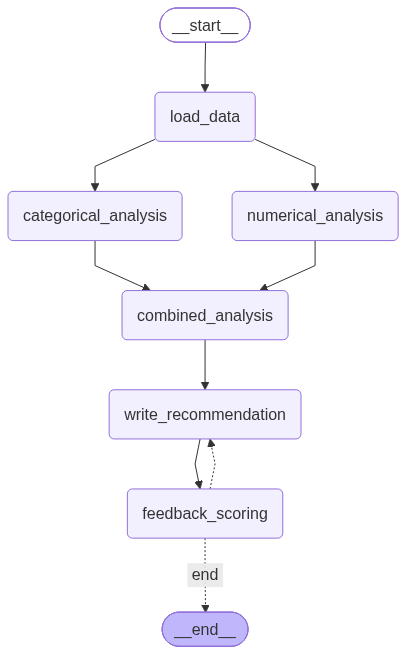

In [124]:

# Visualize the graph
display(Image(app.get_graph().draw_mermaid_png()))

In [125]:
result = app.invoke({
    "counter": 0,
    "feedback_report": "",
    "feedback_history": [],
    "score_history": [],
    "recommendation_history": []
})

**Data quality recommendations**  
Dataset size is 10,000 rows; percentages below use that denominator unless identified as applying only to non-null values. The profile reports no parse-failure counts or raw value examples, so these should be measured before any conversion or correction.

- **Transaction ID** — No missing or duplicate values are reported (10,000 populated, 10,000 distinct), so no value repairs are indicated from this profile.  
  Check the required ID format and test duplicates after trimming whitespace and applying the system’s case rules; record any failures for review. Do not treat sequence gaps as errors unless the ID-generation rules require continuity.

- **Item** — 333 values are null (3.33%); 10 distinct non-null values are reported, but their validity is not established by the profile.  
  Compare values with the owner-approved item list, normalize only approved whitespace/case or alias variants, and review unmatched or ambiguous labels rather than guessing. 

In [130]:
result['feedback_report']


'This is a strong, cautious report that distinguishes observed profile facts from unverified assumptions. It states the denominator, avoids claiming that distinct values are valid, and appropriately avoids unsupported imputation or automatic correction. The field-specific guidance is especially useful for text-typed numeric fields, category validation, transaction-total reconciliation, and the `UNKNOWN` date value. The combined 3.18% for null and `UNKNOWN` dates is correctly described as missing-like rather than treating the two representations as identical. The recommendations to preserve raw values, document provenance, and monitor quality are also sound.\n\nTo make the report more actionable, add a concise remediation plan with priority, accountable data owner, authoritative source or matching method for recovery, expected disposition when recovery fails, and a review/approval step before corrections are applied. For example, specify how recovered values will be matched to transacti